In [1]:
# Import initial libraries
import pandas as pd
import numpy as np
import boto3
from io import StringIO
import matplotlib.pyplot as plt

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Load your modeling dataset from S3
# Replace the path below with your actual S3 path from Day 26
s3 = boto3.client('s3')
bucket_name = 'cmse492-monislow-nyc311-975049958391-us-east-1-an'
file_name = 'modeling/data_resolution_time/data_resolution_time.csv'

obj = s3.get_object(Bucket=bucket_name, Key=file_name)
data = obj['Body'].read().decode('utf-8')
# dropping zip codes due to missing values and difficulty one-hot encoding
# dropping problem since they have been simplified using problem_category
# there are way too many problem types for a train-test split to capture all of them
df = pd.read_csv(StringIO(data)).drop(['incident_zip', 'problem'], axis=1)

print(f"Shape: {df.shape}")
df.head()

Shape: (173870, 6)


,agency,borough,day_of_week,hour_of_day,problem_category,resolved_quickly
0,HPD,BRONX,4,8,housing,1
1,HPD,MANHATTAN,4,8,housing,1
2,NYPD,QUEENS,4,8,other,1
3,DOT,BRONX,4,8,traffic,1
4,NYPD,QUEENS,4,8,traffic,1


In [3]:
# Quick data check
print("Columns:", df.columns.tolist())
print("\nMissing values:")
print(df.isnull().sum())
print("\nData types:")
print(df.dtypes)

Columns: ['agency', 'borough', 'day_of_week', 'hour_of_day', 'problem_category', 'resolved_quickly']

Missing values:
agency              0
borough             0
day_of_week         0
hour_of_day         0
problem_category    0
resolved_quickly    0
dtype: int64

Data types:
agency              object
borough             object
day_of_week          int64
hour_of_day          int64
problem_category    object
resolved_quickly     int64
dtype: object


In [4]:
# Define feature columns and target column
# Replace these with your actual column names
feature_cols = df.columns[:-1]
target_col   = 'resolved_quickly'

X = df[feature_cols]
y = df[target_col]

print(f"Features: {feature_cols}")
print(f"Target: {target_col}")
print(f"\nTarget distribution:")
print(y.value_counts())
print(f"\nClass balance: {y.value_counts(normalize=True).round(3).to_dict()}")

Features: Index(['agency', 'borough', 'day_of_week', 'hour_of_day', 'problem_category'], dtype='object')
Target: resolved_quickly

Target distribution:
resolved_quickly
1    146158
0     27712
Name: count, dtype: int64

Class balance: {1: 0.841, 0: 0.159}


In [5]:
# Import train_test_split for splitting the data
from sklearn.model_selection import train_test_split

# Train/test split: 80% train, 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=492,
    stratify=y
)

print(f"Training set:  {X_train.shape[0]} rows")
print(f"Test set:      {X_test.shape[0]} rows")
print(f"\nClass balance in training set:")
print(y_train.value_counts(normalize=True).round(3))
print(f"\nClass balance in test set:")
print(y_test.value_counts(normalize=True).round(3))

Training set:  139096 rows
Test set:      34774 rows

Class balance in training set:
resolved_quickly
1    0.841
0    0.159
Name: proportion, dtype: float64

Class balance in test set:
resolved_quickly
1    0.841
0    0.159
Name: proportion, dtype: float64


In [6]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

# Identify categorical vs. numeric columns automatically
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = X.select_dtypes(include=['number']).columns.tolist()

print(f"Categorical columns ({len(cat_cols)}): {cat_cols}")
print(f"Numeric columns     ({len(num_cols)}): {num_cols}")

# Build the transformer:
#   - OneHotEncoder for categorical columns
#     drop='first'         avoids multicollinearity (k-1 dummies per feature)
#     sparse_output=False  returns a regular numpy array (easier to inspect)
#     handle_unknown='ignore'  silently zeros out categories not seen in training
#   - StandardScaler for numeric columns -- helpful to standardize inputs for logistic regression, especially when there are different units involved
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='error'), cat_cols),
        ('num', StandardScaler(), num_cols),  # scale numeric columns
    ]
)

# Fit ONLY on training data, then apply to both splits
X_train_enc = preprocessor.fit_transform(X_train)
X_test_enc  = preprocessor.transform(X_test)

# Recover feature names for later coefficient inspection
ohe_names = preprocessor.named_transformers_['cat'].get_feature_names_out(cat_cols).tolist()
encoded_feature_names = ohe_names + num_cols

print(f"\nEncoded feature matrix shape: {X_train_enc.shape}")
print(f"Total features after encoding: {len(encoded_feature_names)}")
print(f"\nFirst few encoded feature names: {encoded_feature_names[:10]}")

Categorical columns (3): ['agency', 'borough', 'problem_category']
Numeric columns     (2): ['day_of_week', 'hour_of_day']

Encoded feature matrix shape: (139096, 23)
Total features after encoding: 23

First few encoded feature names: ['agency_DEP', 'agency_DHS', 'agency_DOB', 'agency_DOE', 'agency_DOHMH', 'agency_DOT', 'agency_DPR', 'agency_DSNY', 'agency_HPD', 'agency_NYPD']


In [7]:
# Import the logistic regression model
from sklearn.linear_model import LogisticRegression

# Train the logistic regression baseline (adjust the model type and parameters as needed for your specific task)
model = LogisticRegression(max_iter=1000, random_state=492)
model.fit(X_train_enc, y_train)

print("Model trained successfully.")
print(f"Classes: {model.classes_}")

Model trained successfully.
Classes: [0 1]


In [8]:
# Inspect the model coefficients
# After encoding, use encoded_feature_names instead of feature_cols
coef_df = pd.DataFrame({
    'feature': encoded_feature_names,
    'coefficient': model.coef_[0]
}).sort_values('coefficient', ascending=False)

print("Model coefficients (top 10 by magnitude):")
print(coef_df.head(10).to_string(index=False))
print("\nPositive coefficient = feature pushes toward the positive class")
print("Negative coefficient = feature pushes toward the negative class")

Model coefficients (top 10 by magnitude):
                 feature  coefficient
             agency_NYPD     8.712429
            agency_DOHMH     1.556430
              agency_DEP     1.549507
              agency_DHS     1.365644
             agency_DSNY     1.103470
              agency_DOE     0.946282
              agency_DOB     0.793162
problem_category_traffic     0.502191
              agency_DPR     0.362869
             hour_of_day     0.029306

Positive coefficient = feature pushes toward the positive class
Negative coefficient = feature pushes toward the negative class


In [9]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

# Generate predictions on the test set
y_pred = model.predict(X_test_enc)

# Compute metrics
acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec  = recall_score(y_test, y_pred, zero_division=0)

print(f"Accuracy:  {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall:    {rec:.3f}")

Accuracy:  0.847
Precision: 0.853
Recall:    0.988


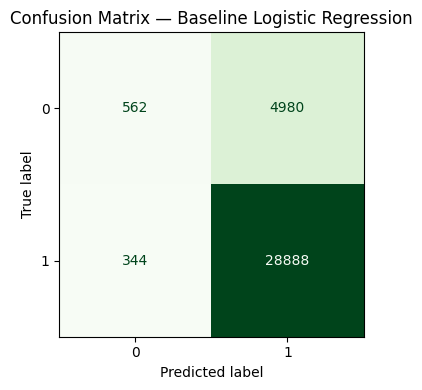

Confusion matrix saved to ../reports/figures/confusion_matrix.png


In [11]:
# Plot the confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)

fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, colorbar=False, cmap='Greens')
ax.set_title('Confusion Matrix — Baseline Logistic Regression')
plt.tight_layout()
plt.savefig('../reports/figures/confusion_matrix.png', dpi=120)
plt.show()
print("Confusion matrix saved to ../reports/figures/confusion_matrix.png")

In [12]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.62      0.10      0.17      5542
           1       0.85      0.99      0.92     29232

    accuracy                           0.85     34774
   macro avg       0.74      0.54      0.54     34774
weighted avg       0.82      0.85      0.80     34774

